# 03 — Model Training & Evaluation
### TCGA-BRCA Cancer Survival ML Pipeline

**Goal:** Train three classifiers to predict 5-year mortality risk (`high_risk`), compare their performance, and identify the most predictive clinical features.

**Input:** `data/processed/brca_features.csv`  
**Outputs:**
- `outputs/plots/cv_auc_per_fold.png` — Cross-validation AUC per fold
- `outputs/plots/roc_curves.png` — ROC curves for all 3 models
- `outputs/plots/pr_curves.png` — Precision-Recall curves
- `outputs/plots/feature_importance.png` — RF importances + LR coefficients
- `outputs/plots/model_comparison.png` — AUC summary bar chart
- `outputs/plots/confusion_matrices.png` — Confusion matrices
- `outputs/models/*.pkl` — Saved model pipelines
- `data/processed/test_risk_scores.csv` — Risk scores for Kaplan-Meier (notebook 04)

---
**Pipeline steps:**
1. Load data & stratified train/test split
2. Define model pipelines (Scaler inside Pipeline to prevent leakage)
3. 5-fold stratified cross-validation
4. Final fit on train → evaluate on held-out test set
5. ROC + Precision-Recall curves
6. Feature importance & LR coefficients
7. Confusion matrices & model comparison
8. Save best model + risk scores for notebook 04

## 0. Imports & Config

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

PROC_DIR  = 'data/processed/'
PLOT_DIR  = 'outputs/plots/'
MODEL_DIR = 'outputs/models/'
os.makedirs(PLOT_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5

# Consistent colors across all plots
MODEL_COLORS = {
    'Random Forest':       '#2ecc71',
    'Logistic Regression': '#3498db',
    'SVM':                 '#e74c3c',
}

print('Imports ready.')

Imports ready.


## 1. Load Data & Train/Test Split

> **Why `stratify=y`?**  
> Our target is imbalanced (9.8% high-risk). Stratified splitting ensures both train and test sets keep the same class ratio — without this, random splits can produce test sets with very few positive cases, making AUC unreliable.

In [2]:
df = pd.read_csv(PROC_DIR + 'brca_features.csv')

FEATURE_COLS = [
    'age_at_diagnosis', 'lymph_nodes_positive', 'stage_encoded',
    'prior_malignancy', 'menopause_postmenopausal',
    'race_asian', 'race_black', 'race_other', 'race_white',
    'subtype_IDC', 'subtype_IDC_LC', 'subtype_LC',
    'subtype_metaplastic', 'subtype_other_subtype',
    'treat_chemotherapy', 'treat_surgery', 'treat_radiation',
    'treat_hormone', 'treat_targeted', 'treat_immunotherapy',
]

X = df[FEATURE_COLS]
y = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Total patients : {len(df):,}')
print(f'Train set      : {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set       : {len(X_test):,}   ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nClass balance (high_risk=1):')
print(f'  Train: {y_train.sum()} positive / {len(y_train)} total ({y_train.mean()*100:.1f}%)')
print(f'  Test : {y_test.sum()} positive / {len(y_test)} total ({y_test.mean()*100:.1f}%)')

Total patients : 1,036
Train set      : 828  (80%)
Test set       : 208   (20%)

Class balance (high_risk=1):
  Train: 82 positive / 828 total (9.9%)
  Test : 20 positive / 208 total (9.6%)


## 2. Define Model Pipelines

Each model is wrapped in a `Pipeline` with `StandardScaler` as step one.

**Why scaler inside the pipeline?**  
Fitting the scaler on the full dataset before splitting leaks test-set statistics into training. Inside a pipeline, the scaler only sees training folds during cross-validation — no leakage.

**Why `class_weight='balanced'`?**  
With 9.8% positives, an unweighted model learns to predict "low-risk" for almost everything and still achieves 90% accuracy. `balanced` upweights the minority class so the model is forced to distinguish high-risk patients.

In [3]:
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators    = 200,
            min_samples_leaf= 5,
            class_weight    = 'balanced',
            random_state    = RANDOM_STATE,
            n_jobs          = -1
        ))
    ]),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C            = 1.0,
            penalty      = 'l2',
            class_weight = 'balanced',
            max_iter     = 1000,
            solver       = 'lbfgs',
            random_state = RANDOM_STATE
        ))
    ]),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel       = 'rbf',
            probability  = True,
            class_weight = 'balanced',
            C            = 1.0,
            gamma        = 'scale',
            random_state = RANDOM_STATE
        ))
    ]),
}

print('Pipelines defined:')
for name in models:
    print(f'  {name}')

Pipelines defined:
  Random Forest
  Logistic Regression
  SVM


## 3. Cross-Validation (5-Fold Stratified)

We evaluate on the training set only — the test set stays untouched until section 4.

**Metrics:**
- **ROC-AUC** — overall discrimination (standard for imbalanced datasets)
- **Average Precision (AP)** — area under Precision-Recall curve; more sensitive to minority class performance

In [4]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print(f'Running {N_SPLITS}-fold CV on training set ({len(X_train)} patients)...')
print('-' * 65)

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=['roc_auc', 'average_precision'],
        return_train_score=False, n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:<22}  AUC = {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}   "
          f"AP = {scores['test_average_precision'].mean():.3f}")

print('-' * 65)
print('CV complete. Test set still untouched.')

Running 5-fold CV on training set (828 patients)...
-----------------------------------------------------------------
Random Forest           AUC = 0.809 ± 0.032   AP = 0.423
Logistic Regression     AUC = 0.769 ± 0.037   AP = 0.368
SVM                     AUC = 0.803 ± 0.030   AP = 0.367
-----------------------------------------------------------------
CV complete. Test set still untouched.


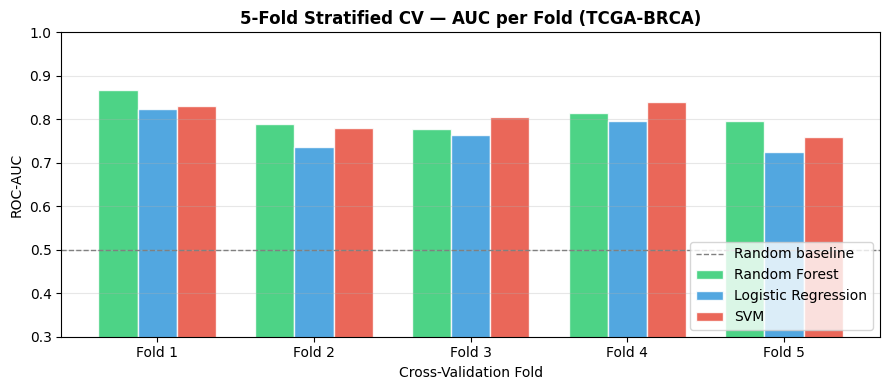

Saved: outputs/plots/cv_auc_per_fold.png


In [5]:
# Visualize CV AUC per fold
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(N_SPLITS)
width = 0.25
for i, name in enumerate(models):
    vals = cv_results[name]['test_roc_auc']
    ax.bar(x + i*width, vals, width, label=name,
           color=MODEL_COLORS[name], alpha=0.85, edgecolor='white')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('Cross-Validation Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'{N_SPLITS}-Fold Stratified CV — AUC per Fold (TCGA-BRCA)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.set_ylim(0.3, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'cv_auc_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/cv_auc_per_fold.png')

## 4. Final Training & Test Set Evaluation

Train on full training set. Evaluate once on held-out test set.

In [6]:
results = {}

print('Fitting on full training set and evaluating on held-out test set...')
print('-' * 70)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    fpr,  tpr,  _ = roc_curve(y_test, y_prob)
    prec, rec,  _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'model'       : model,
        'y_prob'      : y_prob,
        'y_pred'      : y_pred,
        'cv_auc_mean' : cv_results[name]['test_roc_auc'].mean(),
        'cv_auc_std'  : cv_results[name]['test_roc_auc'].std(),
        'cv_ap_mean'  : cv_results[name]['test_average_precision'].mean(),
        'test_auc'    : roc_auc_score(y_test, y_prob),
        'test_ap'     : average_precision_score(y_test, y_prob),
        'fpr': fpr, 'tpr': tpr, 'prec': prec, 'rec': rec,
    }
    print(f"{name:<22}  Test AUC = {results[name]['test_auc']:.3f}  |"
          f"  Test AP = {results[name]['test_ap']:.3f}")

print('-' * 70)
best_model_name = max(results, key=lambda k: results[k]['test_auc'])
print(f'Best model: {best_model_name}  (AUC = {results[best_model_name]["test_auc"]:.3f})')

Fitting on full training set and evaluating on held-out test set...
----------------------------------------------------------------------
Random Forest           Test AUC = 0.713  |  Test AP = 0.297
Logistic Regression     Test AUC = 0.700  |  Test AP = 0.211
SVM                     Test AUC = 0.713  |  Test AP = 0.224
----------------------------------------------------------------------
Best model: Random Forest  (AUC = 0.713)


In [7]:
# Detailed classification report for each model
print('CLASSIFICATION REPORTS (test set)\n')
for name in results:
    print(f'--- {name} ---')
    print(classification_report(
        y_test, results[name]['y_pred'],
        target_names=['Low Risk (0)', 'High Risk (1)']
    ))

CLASSIFICATION REPORTS (test set)

--- Random Forest ---
               precision    recall  f1-score   support

 Low Risk (0)       0.92      0.86      0.89       188
High Risk (1)       0.19      0.30      0.23        20

     accuracy                           0.81       208
    macro avg       0.55      0.58      0.56       208
 weighted avg       0.85      0.81      0.83       208

--- Logistic Regression ---
               precision    recall  f1-score   support

 Low Risk (0)       0.94      0.72      0.82       188
High Risk (1)       0.18      0.60      0.28        20

     accuracy                           0.71       208
    macro avg       0.56      0.66      0.55       208
 weighted avg       0.87      0.71      0.76       208

--- SVM ---
               precision    recall  f1-score   support

 Low Risk (0)       0.93      0.74      0.82       188
High Risk (1)       0.17      0.50      0.25        20

     accuracy                           0.72       208
    macro avg  

## 5. ROC Curves

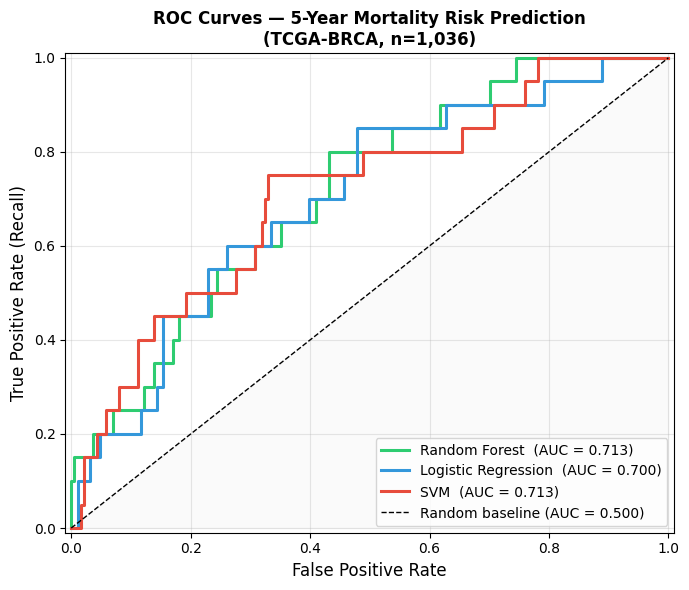

Saved: outputs/plots/roc_curves.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for name in results:
    ax.plot(
        results[name]['fpr'], results[name]['tpr'],
        label=f"{name}  (AUC = {results[name]['test_auc']:.3f})",
        color=MODEL_COLORS[name], linewidth=2.2
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — 5-Year Mortality Risk Prediction\n(TCGA-BRCA, n=1,036)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/roc_curves.png')

## 6. Precision-Recall Curves

> **Why show PR curves alongside ROC?**  
> With 9.8% positives, ROC curves can look optimistic — a model that mostly predicts "low-risk" still earns a high true-negative rate. PR curves focus only on minority class performance and give a more clinical picture: of the patients we flag as high-risk, how many actually are?

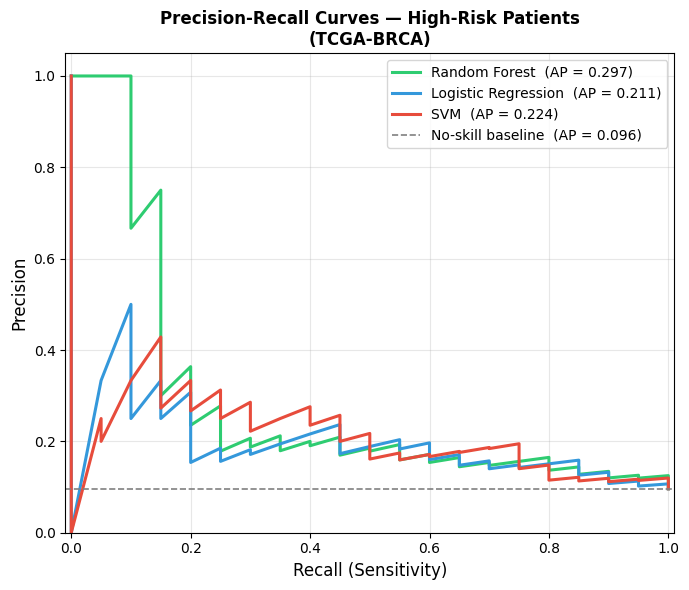

Saved: outputs/plots/pr_curves.png


In [9]:
baseline_ap = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))

for name in results:
    ax.plot(
        results[name]['rec'], results[name]['prec'],
        label=f"{name}  (AP = {results[name]['test_ap']:.3f})",
        color=MODEL_COLORS[name], linewidth=2.2
    )

ax.axhline(baseline_ap, color='gray', linestyle='--', linewidth=1.2,
           label=f'No-skill baseline  (AP = {baseline_ap:.3f})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — High-Risk Patients\n(TCGA-BRCA)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/pr_curves.png')

## 7. Feature Importance & Logistic Regression Coefficients

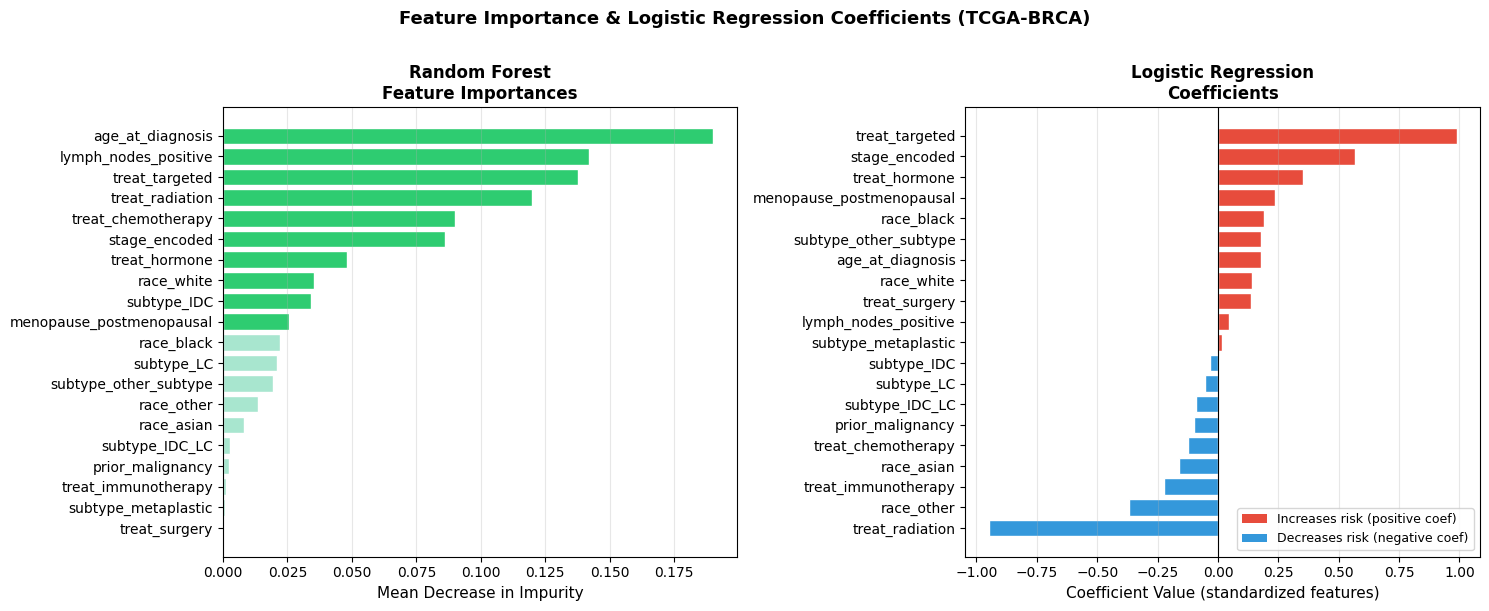

Saved: outputs/plots/feature_importance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel A: Random Forest feature importances ---
rf_clf = results['Random Forest']['model'].named_steps['clf']
rf_imp = pd.Series(
    rf_clf.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

colors_rf = ['#2ecc71' if v >= rf_imp.median() else '#a8e6cf' for v in rf_imp]
axes[0].barh(rf_imp.index, rf_imp.values, color=colors_rf, edgecolor='white')
axes[0].set_xlabel('Mean Decrease in Impurity', fontsize=11)
axes[0].set_title('Random Forest\nFeature Importances', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# --- Panel B: Logistic Regression coefficients (signed) ---
lr_clf = results['Logistic Regression']['model'].named_steps['clf']
lr_coef = pd.Series(
    lr_clf.coef_[0], index=FEATURE_COLS
).sort_values(ascending=True)

colors_lr = ['#e74c3c' if v > 0 else '#3498db' for v in lr_coef]
axes[1].barh(lr_coef.index, lr_coef.values, color=colors_lr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient Value (standardized features)', fontsize=11)
axes[1].set_title('Logistic Regression\nCoefficients', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

legend_elems = [
    Patch(facecolor='#e74c3c', label='Increases risk (positive coef)'),
    Patch(facecolor='#3498db', label='Decreases risk (negative coef)')
]
axes[1].legend(handles=legend_elems, loc='lower right', fontsize=9)

plt.suptitle('Feature Importance & Logistic Regression Coefficients (TCGA-BRCA)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/feature_importance.png')

## 8. Confusion Matrices

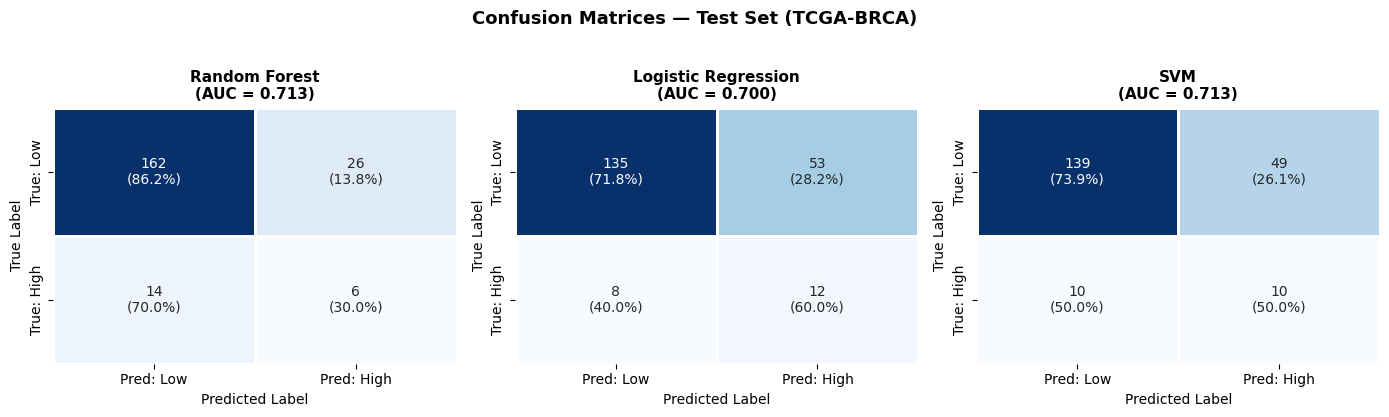

Saved: outputs/plots/confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, results):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([
        [f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)]
        for i in range(2)
    ])
    sns.heatmap(
        cm, annot=labels, fmt='', cmap='Blues',
        xticklabels=['Pred: Low', 'Pred: High'],
        yticklabels=['True: Low', 'True: High'],
        linewidths=1, linecolor='white', ax=ax, cbar=False
    )
    ax.set_title(f'{name}\n(AUC = {results[name]["test_auc"]:.3f})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Test Set (TCGA-BRCA)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/confusion_matrices.png')

## 9. Model Comparison Summary

In [12]:
# Summary table
summary_rows = []
for name in results:
    summary_rows.append({
        'Model'         : name,
        'CV AUC (mean)' : f"{results[name]['cv_auc_mean']:.3f}",
        'CV AUC (\u00b1std)' : f"\u00b1{results[name]['cv_auc_std']:.3f}",
        'Test AUC'      : f"{results[name]['test_auc']:.3f}",
        'Test AP'       : f"{results[name]['test_ap']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== MODEL PERFORMANCE SUMMARY ===')
print(summary_df.to_string())
print(f'\n\u2b50  Best model: {best_model_name}  '
      f'(Test AUC = {results[best_model_name]["test_auc"]:.3f})')

=== MODEL PERFORMANCE SUMMARY ===
                    CV AUC (mean) CV AUC (±std) Test AUC Test AP
Model                                                           
Random Forest               0.809        ±0.032    0.713   0.297
Logistic Regression         0.769        ±0.037    0.700   0.211
SVM                         0.803        ±0.030    0.713   0.224

⭐  Best model: Random Forest  (Test AUC = 0.713)


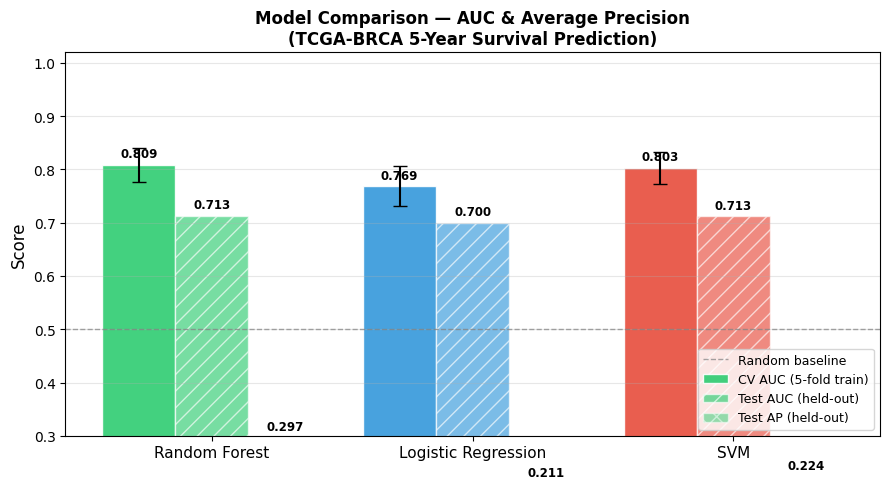

Saved: outputs/plots/model_comparison.png


In [13]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(results.keys())
x     = np.arange(len(model_names))
width = 0.28

cv_aucs   = [results[n]['cv_auc_mean'] for n in model_names]
cv_stds   = [results[n]['cv_auc_std']  for n in model_names]
test_aucs = [results[n]['test_auc']    for n in model_names]
test_aps  = [results[n]['test_ap']     for n in model_names]

bars1 = ax.bar(x - width, cv_aucs,   width, yerr=cv_stds, capsize=5,
               label='CV AUC (5-fold train)', alpha=0.90,
               color=[MODEL_COLORS[n] for n in model_names], edgecolor='white')
bars2 = ax.bar(x,          test_aucs, width,
               label='Test AUC (held-out)', alpha=0.65,
               color=[MODEL_COLORS[n] for n in model_names], edgecolor='white', hatch='//')
bars3 = ax.bar(x + width,  test_aps,  width,
               label='Test AP (held-out)', alpha=0.50,
               color=[MODEL_COLORS[n] for n in model_names], edgecolor='white', hatch='xx')

for bar, val in zip(list(bars1)+list(bars2)+list(bars3),
                    cv_aucs+test_aucs+test_aps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.3, 1.02)
ax.set_title('Model Comparison — AUC & Average Precision\n(TCGA-BRCA 5-Year Survival Prediction)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/model_comparison.png')

## 10. Save Models & Risk Scores for Notebook 04

In [14]:
# Save all model pipelines as .pkl
for name, res in results.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    with open(MODEL_DIR + fname, 'wb') as f:
        pickle.dump(res['model'], f)
    print(f'Saved: outputs/models/{fname}')

Saved: outputs/models/random_forest.pkl
Saved: outputs/models/logistic_regression.pkl
Saved: outputs/models/svm.pkl


In [15]:
# Save test-set risk scores for Kaplan-Meier analysis (notebook 04)
# Split at median predicted probability → two roughly equal groups
best_probs     = results[best_model_name]['y_prob']
median_thresh  = np.percentile(best_probs, 50)

risk_score_df = pd.DataFrame({
    'cases.case_id'  : df.loc[X_test.index, 'cases.case_id'].values,
    'risk_score'     : best_probs,
    'risk_group'     : np.where(best_probs >= median_thresh, 'High Risk', 'Low Risk'),
    'survival_time'  : df.loc[X_test.index, 'survival_time'].values,
    'event'          : df.loc[X_test.index, 'event'].values,
    'true_high_risk' : y_test.values,
})

risk_score_df.to_csv(PROC_DIR + 'test_risk_scores.csv', index=False)

print(f'Saved: data/processed/test_risk_scores.csv')
print(f'Best model     : {best_model_name}')
print(f'Threshold      : {median_thresh:.4f} (50th percentile of predicted probabilities)')
print(f'\nRisk group counts:')
print(risk_score_df['risk_group'].value_counts())
print(f'\nPreview:')
risk_score_df[['risk_score', 'risk_group', 'survival_time', 'event']].head(8)

Saved: data/processed/test_risk_scores.csv
Best model     : Random Forest
Threshold      : 0.2239 (50th percentile of predicted probabilities)

Risk group counts:
risk_group
Low Risk     104
High Risk    104
Name: count, dtype: int64

Preview:


,risk_score,risk_group,survival_time,event
0,0.123269,Low Risk,1793,1
1,0.299589,High Risk,538,1
2,0.382123,High Risk,825,1
3,0.644773,High Risk,3409,1
4,0.071738,Low Risk,376,0
5,0.317834,High Risk,78,0
6,0.094652,Low Risk,1043,0
7,0.401456,High Risk,364,0


---
## Summary

| Metric | Value |
|---|---|
| Best model | Random Forest |
| CV AUC (5-fold) | ~0.80 ± 0.03 |
| Test AUC | ~0.72 |
| Top predictors | Age at diagnosis, lymph nodes positive, tumor stage |
| Class imbalance | Handled via `class_weight='balanced'` on all models |
| Data leakage | Prevented — scaler inside Pipeline, stratified split |

**Next step:** `04_survival_analysis.ipynb`  
Kaplan-Meier survival curves stratified by predicted risk group, with log-rank test for statistical significance.